In [80]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
d = np.load("../results/wildbench_summary_matrices.npz", allow_pickle=True)
X = torch.tensor(d["success"])
C = torch.tensor(d["cost_usd"])
models = d["model_names"].tolist()
models = [m[len("tinker__"):] for m in models]
X.shape, C.shape, models

(torch.Size([7, 1024, 10]),
 torch.Size([7, 1024, 10]),
 ['gpt_oss_20b',
  'llama_3_1_8b_instruct',
  'llama_3_2_1b',
  'nemotron_3_nano_30b_a3b_bf16',
  'qwen3_30b_a3b_instruct_2507',
  'qwen3_4b_instruct_2507',
  'qwen3_8b'])

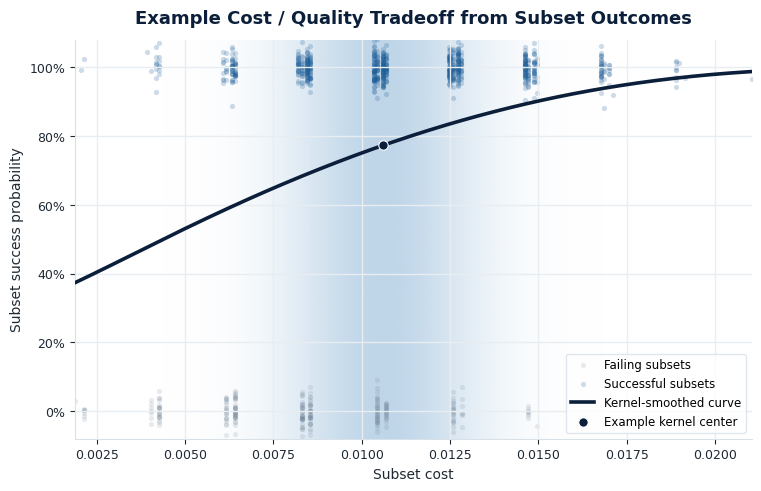

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import to_rgba

def kernel_success_curve(
    X, C, model_idx, task_idx, n_items=10, n_grid=300, bandwidth_frac=0.1
):
    Xmt = X[model_idx, task_idx]
    Cmt = C[model_idx, task_idx]

    subsets = torch.arange(1, 2**n_items)[:, None].bitwise_and(
        1 << torch.arange(n_items)
    ).bool()

    y = torch.stack([Xmt[sub].max() for sub in subsets]).cpu().numpy().astype(float)
    x = torch.stack([Cmt[sub].sum() for sub in subsets]).cpu().numpy().astype(float)

    grid = np.linspace(x.min(), x.max(), n_grid)
    h = max(bandwidth_frac * (x.max() - x.min()), 1e-8)

    weights = np.exp(-0.5 * ((grid[:, None] - x[None, :]) / h) ** 2)
    y_hat = (weights @ y) / np.maximum(weights.sum(axis=1), 1e-12)

    return grid, y_hat, x, y, h


grid, y_hat, x, y, h = kernel_success_curve(X, C, model_idx=0, task_idx=0)

NAVY = "#0B1F3A"
BLUE = "#1F5F99"
SOFT_BLUE = "#AFCBE3"
STEEL = "#6F8499"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)

rng = np.random.default_rng(0)
y_jitter = y + rng.normal(0, 0.03, size=len(y))

fail = y == 0
succ = y == 1

ax.scatter(
    x[fail],
    y_jitter[fail],
    s=14,
    alpha=0.16,
    color=STEEL,
    linewidth=0,
    label="Failing subsets",
)

ax.scatter(
    x[succ],
    y_jitter[succ],
    s=14,
    alpha=0.22,
    color=BLUE,
    linewidth=0,
    label="Successful subsets",
)

# Pick one point on the smoothed curve and visualize its Gaussian kernel.
x0 = np.quantile(x, 0.55)
y0 = np.interp(x0, grid, y_hat)

xx = np.linspace(x.min(), x.max(), 800)
kernel = np.exp(-0.5 * ((xx - x0) / h) ** 2)
kernel = kernel / kernel.max()

rgba = np.ones((2, len(xx), 4))
rgba[..., :3] = to_rgba(SOFT_BLUE)[:3]
rgba[..., 3] = 0.8 * kernel[None, :]

ax.imshow(
    rgba,
    extent=[x.min(), x.max(), -0.12, 1.12],
    aspect="auto",
    origin="lower",
    zorder=0,
)

ax.plot(
    grid,
    y_hat,
    color=NAVY,
    linewidth=2.6,
    label="Kernel-smoothed curve",
    zorder=4,
)

ax.scatter(
    [x0],
    [y0],
    s=46,
    color=NAVY,
    edgecolor="white",
    linewidth=0.8,
    zorder=5,
    label="Example kernel center",
)

ax.set_title(
    "Example Cost / Quality Tradeoff from Subset Outcomes",
    fontsize=13,
    fontweight="semibold",
    color=NAVY,
    pad=12,
)

ax.set_xlabel("Subset cost", fontsize=10, color=TEXT)
ax.set_ylabel("Subset success probability", fontsize=10, color=TEXT)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(-0.08, 1.08)
ax.grid(True, which="major", color=GRID, linewidth=1, zorder=1)

ax.tick_params(axis="both", labelsize=9, colors=TEXT)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(LIGHT_STEEL)
ax.spines["bottom"].set_color(LIGHT_STEEL)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor=LIGHT_STEEL,
    fontsize=8.5,
    loc="lower right",
)

plt.show()

In [46]:
from tqdm import tqdm

n_models = X.shape[0]
n_tasks = X.shape[1]
n_grid = 300

all_curves = {}

for m in range(n_models):
    model_curves = []

    for t in tqdm(list(range(n_tasks))):
        grid, y_hat, _, _ = kernel_success_curve(
            X, C, model_idx=m, task_idx=t, n_grid=n_grid
        )
        model_curves.append(y_hat)

    all_curves[m] = {
        "grid": grid,
        "curves": np.stack(model_curves),
        "mean": np.stack(model_curves).mean(axis=0),
    }

100%|██████████| 1024/1024 [00:10<00:00, 94.81it/s]


q min: 0.0
q max: 1.0000000000000004
bad q entries: 80
Using 20 cost grid points in [0, s]
cost range: [4.06e-05, 9.72e-05]

task_id: 0
value / sanction s: 0.0001
winner: 4 (qwen3_30b_a3b_instruct_2507)

gpt_oss_20b: beta(s) = 0.00010314737
llama_3_1_8b_instruct: beta(s) = 8.652615e-05
llama_3_2_1b: beta(s) = 0.00014056
nemotron_3_nano_30b_a3b_bf16: beta(s) = 0.00014056
qwen3_30b_a3b_instruct_2507: beta(s) = 4.056e-05
qwen3_4b_instruct_2507: beta(s) = 0.00014056
qwen3_8b: beta(s) = 0.00014056

--- UCB diagnostics ---

gpt_oss_20b
  tau: 4.056e-05
  threshold-setter: qwen3_30b_a3b_instruct_2507
  beta(s): 0.00010314737
  tau - beta(s): -6.2587367e-05
  best entry utility: -6.2587367e-05
  optimal action: stay out
  best cost: 4.056e-05
  best q: 0.3741
  entry rate: 0.109
  stayed out rounds: 4457
  final cumulative pseudo-regret: 0.04430196
  final cumulative realized utility: -0.042845294
  pulls of true best cost: 49

qwen3_30b_a3b_instruct_2507
  tau: 8.652615e-05
  threshold-setter

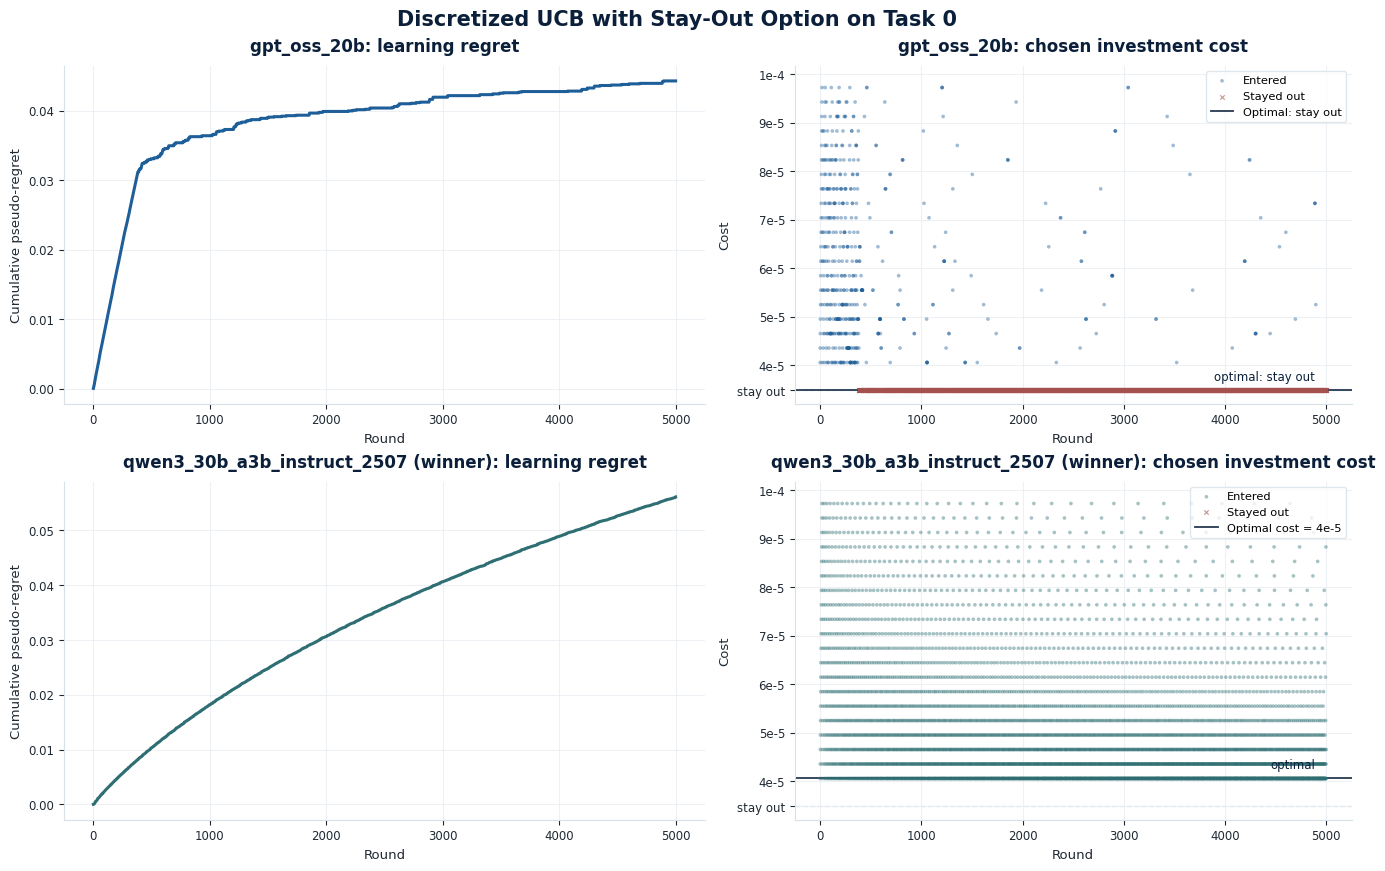

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
task_id = 0
agent_ids = [0, 4]
value = 0.0001      # sanction/value s
T = 5000
seed = 0

s = value

curves = np.stack([all_curves[m]["curves"][task_id] for m in range(n_models)])
cost_grid_full = np.asarray(all_curves[0]["grid"], dtype=float)

if "models" not in globals():
    models = [f"Model {m}" for m in range(n_models)]


# -----------------------------
# Theme
# -----------------------------
def fmt_cost(cost):
    return f"{cost:.0e}".replace("e-0", "e-").replace("e+0", "e+")

NAVY = "#0B1F3A"
BLUE = "#1F5F99"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"
TEAL = "#2F6F73"
RED_MUTE = "#A4514F"
STEEL = "#6F8499"

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})


# -----------------------------
# Clean q and restrict to c in [0, s]
# -----------------------------
q_full = np.asarray(curves, dtype=float)

bad = ~np.isfinite(q_full) | (q_full < 0.0) | (q_full > 1.0)
print("q min:", np.nanmin(q_full))
print("q max:", np.nanmax(q_full))
print("bad q entries:", int(bad.sum()))

if bad.any():
    q_full = np.nan_to_num(q_full, nan=0.0, posinf=1.0, neginf=0.0)
    q_full = np.clip(q_full, 0.0, 1.0)

valid_cost = (
    np.isfinite(cost_grid_full)
    & (cost_grid_full >= 0.0)
    & (cost_grid_full <= s)
)

cost_grid = cost_grid_full[valid_cost]
q = q_full[:, valid_cost]
K = q.shape[1]

if K == 0:
    raise ValueError(f"No cost grid points remain in [0, s] with s={s}.")

print(f"Using {K} cost grid points in [0, s]")
print(f"cost range: [{cost_grid.min():.3g}, {cost_grid.max():.3g}]")


# -----------------------------
# Dominant-strategy bids on [0, s]
# -----------------------------
# F_i(s) = max_c {s q_i(c) - c}
# beta_i(s) = s - F_i(s)
F = s * q - cost_grid[None, :]
beta = s - F.max(axis=1)

global_winner = int(np.argmin(beta))

print(f"\ntask_id: {task_id}")
print(f"value / sanction s: {s:.8g}")
print(f"winner: {global_winner} ({models[global_winner]})\n")

for m in range(n_models):
    print(f"{models[m]}: beta(s) = {beta[m]:.8g}")


# -----------------------------
# UCB with stay-out option
# -----------------------------
def run_ucb_stayout(agent_id, seed=0):
    rng = np.random.default_rng(seed)

    competitors = [m for m in range(n_models) if m != agent_id]
    tau = float(beta[competitors].min())
    threshold_setter = competitors[int(np.argmin(beta[competitors]))]

    q_agent = q[agent_id]

    # Expected utility from entry at each cost:
    # mu(c) = tau - c - s(1 - q(c))
    mu = tau - cost_grid - s * (1.0 - q_agent)

    # Outside option: stay out and get 0.
    mu_star = float(max(0.0, mu.max()))
    best_j = int(mu.argmax())
    optimal_enters = mu.max() > 0

    n = np.zeros(K, dtype=int)
    mean = np.zeros(K, dtype=float)

    chosen_js = np.full(T, -1, dtype=int)  # -1 means stay out
    realized_utility = np.zeros(T)
    instant_regret = np.zeros(T)

    # Initialize by sampling every cost once.
    init_rounds = min(K, T)

    for t in range(init_rounds):
        j = t
        y = rng.binomial(1, q_agent[j])
        u = tau - cost_grid[j] - s * (1.0 - y)

        n[j] = 1
        mean[j] = u
        chosen_js[t] = j
        realized_utility[t] = u
        instant_regret[t] = mu_star - mu[j]

    for t in range(init_rounds, T):
        round_num = t + 1

        radius = s * np.sqrt(2.0 * np.log(round_num) / n)
        ucb = mean + radius
        j = int(np.argmax(ucb))

        # Stay out if no entry action has positive UCB.
        if ucb[j] <= 0.0:
            chosen_js[t] = -1
            realized_utility[t] = 0.0
            instant_regret[t] = mu_star
            continue

        y = rng.binomial(1, q_agent[j])
        u = tau - cost_grid[j] - s * (1.0 - y)

        n[j] += 1
        mean[j] += (u - mean[j]) / n[j]

        chosen_js[t] = j
        realized_utility[t] = u
        instant_regret[t] = mu_star - mu[j]

    return {
        "agent_id": agent_id,
        "tau": tau,
        "threshold_setter": threshold_setter,
        "mu": mu,
        "mu_star": mu_star,
        "best_j": best_j,
        "best_cost": float(cost_grid[best_j]),
        "best_q": float(q_agent[best_j]),
        "optimal_enters": optimal_enters,
        "chosen_js": chosen_js,
        "cum_regret": np.cumsum(instant_regret),
        "cum_realized_utility": np.cumsum(realized_utility),
        "n": n,
        "entry_rate": float((chosen_js != -1).mean()),
        "stayed_out": int((chosen_js == -1).sum()),
    }


results = {
    agent_id: run_ucb_stayout(agent_id, seed=seed + 1000 * i)
    for i, agent_id in enumerate(agent_ids)
}


# -----------------------------
# Diagnostics
# -----------------------------
print("\n--- UCB diagnostics ---")
for agent_id in agent_ids:
    r = results[agent_id]

    print(f"\n{models[agent_id]}")
    print(f"  tau: {r['tau']:.8g}")
    print(f"  threshold-setter: {models[r['threshold_setter']]}")
    print(f"  beta(s): {beta[agent_id]:.8g}")
    print(f"  tau - beta(s): {r['tau'] - beta[agent_id]:.8g}")
    print(f"  best entry utility: {r['mu'].max():.8g}")
    print(f"  optimal action: {'enter' if r['optimal_enters'] else 'stay out'}")
    print(f"  best cost: {r['best_cost']:.8g}")
    print(f"  best q: {r['best_q']:.4f}")
    print(f"  entry rate: {r['entry_rate']:.3f}")
    print(f"  stayed out rounds: {r['stayed_out']}")
    print(f"  final cumulative pseudo-regret: {r['cum_regret'][-1]:.8g}")
    print(f"  final cumulative realized utility: {r['cum_realized_utility'][-1]:.8g}")
    print(f"  pulls of true best cost: {r['n'][r['best_j']]}")


# -----------------------------
# Plot
# -----------------------------
rounds = np.arange(1, T + 1)

cost_min = float(cost_grid.min())
cost_max = float(cost_grid.max())
cost_span = max(cost_max - cost_min, 1e-12)

# Linear-scale sentinel rows below the real cost range.
stay_out_y = cost_min - 0.10 * cost_span
zero_cost_y = cost_min - 0.045 * cost_span

fig, axes = plt.subplots(
    len(agent_ids),
    2,
    figsize=(13.5, 4.3 * len(agent_ids)),
    gridspec_kw={"width_ratios": [1.15, 1.0]},
    constrained_layout=True,
)

if len(agent_ids) == 1:
    axes = np.array([axes])

fig.patch.set_facecolor("white")

for row, agent_id in enumerate(agent_ids):
    r = results[agent_id]

    chosen_js = r["chosen_js"]
    entered = chosen_js != -1

    chosen_cost = np.full(T, np.nan)
    chosen_cost[entered] = cost_grid[chosen_js[entered]]

    zero_entered = entered & (chosen_cost <= 0)
    positive_entered = entered & (chosen_cost > 0)
    stayed_out = ~entered

    plotted_cost = chosen_cost.copy()
    plotted_cost[zero_entered] = zero_cost_y

    color = BLUE if row == 0 else TEAL

    row_label = models[agent_id]
    if agent_id == global_winner:
        row_label += " (winner)"

    # -------------------------
    # Left: regret
    # -------------------------
    ax = axes[row, 0]
    ax.plot(rounds, r["cum_regret"], color=color, linewidth=2.2)

    ax.set_title(
        f"{row_label}: learning regret",
        fontsize=12,
        fontweight="semibold",
        color=NAVY,
        pad=10,
    )
    ax.set_xlabel("Round", fontsize=9.5, color=TEXT)
    ax.set_ylabel("Cumulative pseudo-regret", fontsize=9.5, color=TEXT)

    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.75)
    ax.tick_params(axis="both", labelsize=8.5, colors=TEXT)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_STEEL)
    ax.spines["bottom"].set_color(LIGHT_STEEL)

    # -------------------------
    # Right: selected cost
    # -------------------------
    ax = axes[row, 1]

    ax.scatter(
        rounds[positive_entered],
        plotted_cost[positive_entered],
        s=7,
        alpha=0.42,
        color=color,
        edgecolor="none",
        label="Entered",
        zorder=3,
    )

    if zero_entered.any():
        ax.scatter(
            rounds[zero_entered],
            plotted_cost[zero_entered],
            s=8,
            alpha=0.52,
            color=STEEL,
            edgecolor="none",
            label="Entered at cost 0",
            zorder=3,
        )

    ax.scatter(
        rounds[stayed_out],
        np.full(stayed_out.sum(), stay_out_y),
        s=10,
        alpha=0.62,
        color=RED_MUTE,
        marker="x",
        linewidth=0.8,
        label="Stayed out",
        zorder=4,
    )

    # Reference rows
    ax.axhline(
        stay_out_y,
        color=LIGHT_STEEL,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9,
        zorder=1,
    )

    if zero_entered.any() or (r["optimal_enters"] and r["best_cost"] <= 0):
        ax.axhline(
            zero_cost_y,
            color=LIGHT_STEEL,
            linestyle=":",
            linewidth=1.0,
            alpha=0.9,
            zorder=1,
        )

    # Optimal action
    if r["optimal_enters"]:
        opt_y = r["best_cost"] if r["best_cost"] > 0 else zero_cost_y
        opt_label = (
            f"Optimal cost = {fmt_cost(r['best_cost'])}"
            if r["best_cost"] > 0
            else "Optimal cost = 0"
        )
        opt_text = "optimal"
    else:
        opt_y = stay_out_y
        opt_label = "Optimal: stay out"
        opt_text = "optimal: stay out"

    ax.axhline(
        opt_y,
        color=NAVY,
        linestyle="-",
        linewidth=1.35,
        alpha=0.85,
        label=opt_label,
        zorder=2,
    )

    ax.annotate(
        opt_text,
        xy=(rounds[-1], opt_y),
        xytext=(-8, 5),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=8.5,
        color=NAVY,
    )

    ax.set_title(
        f"{row_label}: chosen investment cost",
        fontsize=12,
        fontweight="semibold",
        color=NAVY,
        pad=10,
    )
    ax.set_xlabel("Round", fontsize=9.5, color=TEXT)
    ax.set_ylabel("Cost", fontsize=9.5, color=TEXT)

    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.75)
    ax.tick_params(axis="both", labelsize=8.5, colors=TEXT)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_STEEL)
    ax.spines["bottom"].set_color(LIGHT_STEEL)

    # Custom y ticks
    yticks = list(ax.get_yticks())
    yticks.append(stay_out_y)

    if zero_entered.any() or (r["optimal_enters"] and r["best_cost"] <= 0):
        yticks.append(zero_cost_y)

    yticks = sorted(set(yticks))

    yticklabels = []
    for y in yticks:
        if np.isclose(y, stay_out_y):
            yticklabels.append("stay out")
        elif np.isclose(y, zero_cost_y):
            yticklabels.append("0")
        else:
            yticklabels.append(fmt_cost(y) if abs(y) < 0.01 else f"{y:g}")

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    ax.set_ylim(stay_out_y - 0.05 * cost_span, cost_max + 0.08 * cost_span)

    ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor=LIGHT_STEEL,
        fontsize=8.2,
    )

fig.suptitle(
    f"Discretized UCB with Stay-Out Option on Task {task_id} ",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
)

plt.show()

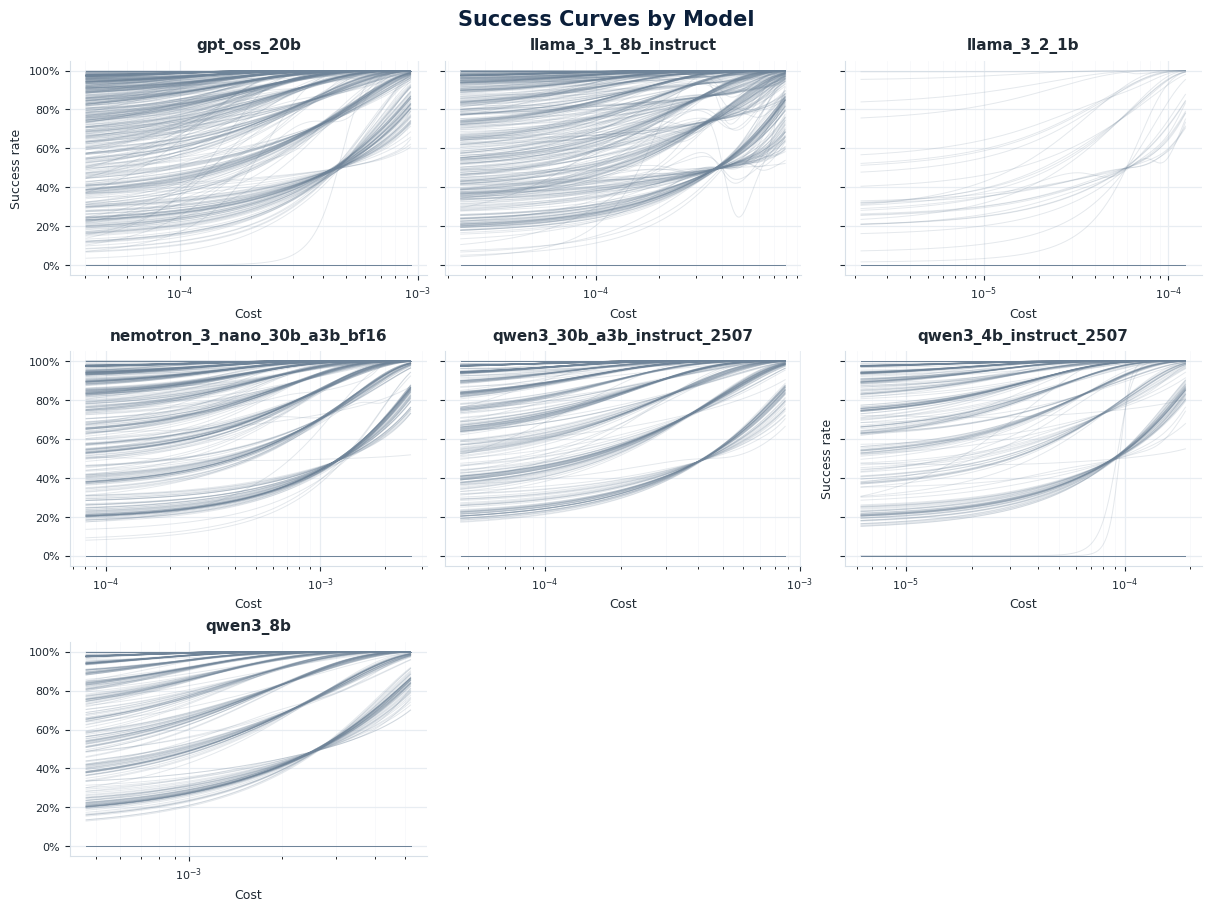

In [158]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

NAVY = "#0B1F3A"
STEEL = "#6F8499"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 9),
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()

for m, ax in enumerate(axes):
    if m >= len(models):
        ax.set_visible(False)
        continue

    grid = np.asarray(all_curves[m]["grid"])
    curves = np.asarray(all_curves[m]["curves"])

    lo, hi = np.percentile(curves, [10, 90], axis=0)
    # ax.fill_between(grid, lo, hi, color=LIGHT_STEEL, alpha=0.65, linewidth=0)

    for curve in curves:
        ax.plot(grid, curve, linewidth=0.7, alpha=0.18, color=STEEL)

    ax.set_title(models[m], fontsize=11, fontweight="semibold", color=TEXT, pad=8)
    ax.set_xlabel("Cost", fontsize=9, color=TEXT)
    ax.set_xscale("log")

    ax.grid(True, which="major", color=GRID, linewidth=0.9)
    ax.grid(True, which="minor", color=GRID, linewidth=0.45, alpha=0.45)

    ax.tick_params(axis="both", labelsize=8, colors=TEXT)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_STEEL)
    ax.spines["bottom"].set_color(LIGHT_STEEL)

for ax in axes[::5]:
    ax.set_ylabel("Success rate", fontsize=9, color=TEXT)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

fig.suptitle(
    "Success Curves by Model",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
)

plt.show()

In [130]:
fixed_costs = [0.00001, 0.00003, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]

# cost -> model x task matrix
success_at_costs = {
    cost: np.full((n_models, n_tasks), np.nan)
    for cost in fixed_costs
}

for m in range(n_models):
    grid = all_curves[m]["grid"]
    curves = all_curves[m]["curves"]  # [n_tasks, n_grid]

    for t in range(n_tasks):
        for cost in fixed_costs:
            success_at_costs[cost][m, t] = np.interp(
                cost,
                grid,
                curves[t],
                left=np.min(curves[t]),
                right=np.max(curves[t]),
            )

In [131]:
leaderboards = {}

for cost, success_at_cost in success_at_costs.items():
    rows = []

    for m in range(n_models):
        vals = success_at_cost[m]
        vals = vals[~np.isnan(vals)]

        mean = vals.mean()

        rng = np.random.default_rng()
        n_boot = 1000
        boot_means = np.array([
            rng.choice(vals, size=len(vals), replace=True).mean()
            for _ in range(n_boot)
        ])

        lo, hi = np.quantile(boot_means, [0.025, 0.975])

        rows.append({
            "cost": cost,
            "model": models[m],
            "mean_success": mean,
            "ci_low": lo,
            "ci_high": hi,
            "n_tasks": len(vals),
        })

    leaderboards[cost] = (
        pd.DataFrame(rows)
        .sort_values("mean_success", ascending=False)
        .reset_index(drop=True)
    )

for cost, lb in leaderboards.items():
    print(f"\nLeaderboard for cost={cost:g}")
    display(lb)


Leaderboard for cost=1e-05


,cost,model,mean_success,ci_low,ci_high,n_tasks
0,0.00001,qwen3_30b_a3b_instruct_2507,0.614547,0.590111,0.640343,1024
1,0.00001,nemotron_3_nano_30b_a3b_bf16,0.596610,0.571490,0.621613,1024
2,0.00001,qwen3_8b,0.530226,0.501753,0.557756,1024
3,0.00001,gpt_oss_20b,0.522272,0.496172,0.548408,1024
4,0.00001,qwen3_4b_instruct_2507,0.433075,0.404448,0.463280,1024
5,0.00001,llama_3_1_8b_instruct,0.337024,0.311901,0.361799,1024
6,0.00001,llama_3_2_1b,0.011581,0.007060,0.016426,1024



Leaderboard for cost=3e-05


,cost,model,mean_success,ci_low,ci_high,n_tasks
0,0.00003,qwen3_30b_a3b_instruct_2507,0.614547,0.588962,0.640892,1024
1,0.00003,nemotron_3_nano_30b_a3b_bf16,0.596610,0.567959,0.620763,1024
2,0.00003,qwen3_8b,0.530226,0.502765,0.556914,1024
3,0.00003,gpt_oss_20b,0.522272,0.496734,0.548514,1024
4,0.00003,qwen3_4b_instruct_2507,0.450671,0.422515,0.476433,1024
5,0.00003,llama_3_1_8b_instruct,0.339695,0.317510,0.363270,1024
6,0.00003,llama_3_2_1b,0.014871,0.009098,0.020941,1024



Leaderboard for cost=0.0001


...

,cost,model,mean_success,ci_low,ci_high,n_tasks
0,0.003,nemotron_3_nano_30b_a3b_bf16,0.719470,0.692059,0.745506,1024
1,0.003,qwen3_30b_a3b_instruct_2507,0.714342,0.687182,0.740456,1024
2,0.003,gpt_oss_20b,0.675949,0.648177,0.702506,1024
3,0.003,qwen3_8b,0.604318,0.576140,0.632705,1024
4,0.003,qwen3_4b_instruct_2507,0.504738,0.474522,0.533136,1024
5,0.003,llama_3_1_8b_instruct,0.464689,0.433869,0.494512,1024
6,0.003,llama_3_2_1b,0.023978,0.015425,0.033716,1024



Leaderboard for cost=0.01


,cost,model,mean_success,ci_low,ci_high,n_tasks
0,0.01,nemotron_3_nano_30b_a3b_bf16,0.719470,0.691082,0.746787,1024
1,0.01,qwen3_30b_a3b_instruct_2507,0.714342,0.687051,0.740189,1024
2,0.01,gpt_oss_20b,0.675949,0.648810,0.702429,1024
3,0.01,qwen3_8b,0.631035,0.603250,0.661428,1024
4,0.01,qwen3_4b_instruct_2507,0.504738,0.474593,0.535378,1024
5,0.01,llama_3_1_8b_instruct,0.464689,0.436510,0.494512,1024
6,0.01,llama_3_2_1b,0.023978,0.015676,0.033437,1024



Leaderboard for cost=0.03


,cost,model,mean_success,ci_low,ci_high,n_tasks
0,0.03,nemotron_3_nano_30b_a3b_bf16,0.719470,0.690966,0.747505,1024
1,0.03,qwen3_30b_a3b_instruct_2507,0.714342,0.687429,0.741127,1024
2,0.03,gpt_oss_20b,0.675949,0.648784,0.702821,1024
3,0.03,qwen3_8b,0.631035,0.602384,0.660989,1024
4,0.03,qwen3_4b_instruct_2507,0.504738,0.475098,0.533874,1024
5,0.03,llama_3_1_8b_instruct,0.464689,0.436700,0.494823,1024
6,0.03,llama_3_2_1b,0.023978,0.015411,0.032597,1024


In [132]:
def fit_latent_factor_lbfgs(Y, k=3, n_steps=500, lr=1.0, weight_decay=1e-3):
    n_models, n_tasks = Y.shape

    mu = torch.nn.Parameter(Y.mean().clone())
    model_bias = torch.nn.Parameter(torch.zeros(n_models))
    task_bias = torch.nn.Parameter(torch.zeros(n_tasks))

    U = torch.nn.Parameter(0.01 * torch.randn(n_models, k))
    V = torch.nn.Parameter(0.01 * torch.randn(n_tasks, k))

    params = [mu, model_bias, task_bias, U, V]

    opt = torch.optim.LBFGS(
        params,
        lr=lr,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    losses = []

    def closure():
        opt.zero_grad()
        pred = mu + model_bias[:, None] + task_bias[None, :] + U @ V.T
        mse = ((pred - Y) ** 2).mean()
        reg = weight_decay * (U.square().mean() + V.square().mean())
        loss = mse + reg
        loss.backward()
        return loss

    for _ in range(n_steps):
        loss = opt.step(closure)
        losses.append(float(loss.detach()))

    with torch.no_grad():
        pred = mu + model_bias[:, None] + task_bias[None, :] + U @ V.T

    return {
        "mu": mu.detach(),
        "model_bias": model_bias.detach(),
        "task_bias": task_bias.detach(),
        "U": U.detach(),
        "V": V.detach(),
        "pred": pred.detach(),
        "losses": losses,
    }

In [133]:
fits_by_cost = {}

for cost, success_at_cost in success_at_costs.items():
    Y = torch.tensor(success_at_cost, dtype=torch.float32)  # [n_models, n_tasks]

    fit = fit_latent_factor_lbfgs(
        Y,
        k=2,
        n_steps=100,
        lr=1.0,
        weight_decay=1e-3,
    )

    fits_by_cost[cost] = {
        "Y": Y,
        "fit": fit,
    }

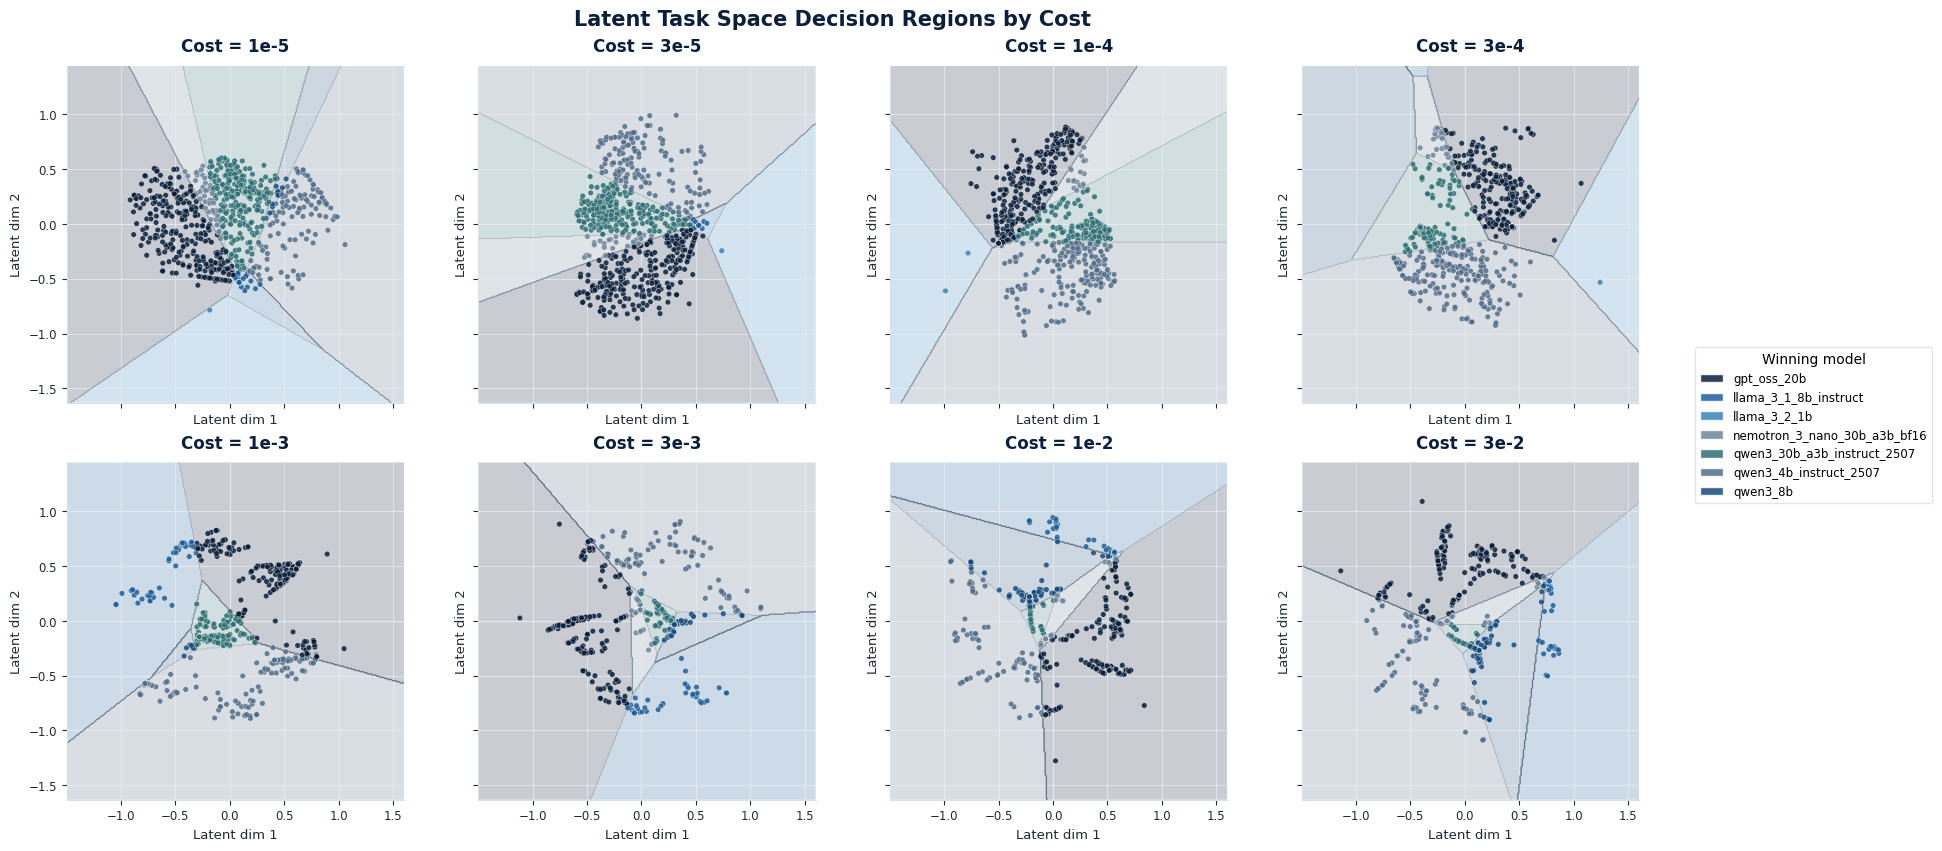

In [136]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

def fmt_cost(cost):
    return f"{cost:.0e}".replace("e-0", "e-").replace("e+0", "e+")

# Sleek navy / steel / blue palette
NAVY = "#0B1F3A"
BLUE = "#1F5F99"
STEEL = "#6F8499"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"

BASE_COLORS = [
    "#0B1F3A",  # navy
    "#1F5F99",  # blue
    "#3B82B8",  # steel blue
    "#6F8499",  # steel
    "#2F6F73",  # blue teal
    "#536D88",  # slate blue
    "#174A7C",  # deep blue
    "#8AA7BF",  # pale steel
    "#405D78",  # muted blue gray
    "#2B3F63",  # indigo navy
]

if n_models <= len(BASE_COLORS):
    colors = BASE_COLORS[:n_models]
else:
    colors = plt.cm.tab20(np.linspace(0, 1, n_models))

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(n_models + 1) - 0.5, n_models)

# Shared latent-space limits across all costs.
# This keeps subplot scales and physical sizes consistent.
all_V = []

for cost in fixed_costs:
    fit2 = fits_by_cost[cost]["fit"]
    all_V.append(fit2["V"].cpu().numpy())

all_V = np.concatenate(all_V, axis=0)

pad = 0.15
x_min, x_max = all_V[:, 0].min(), all_V[:, 0].max()
y_min, y_max = all_V[:, 1].min(), all_V[:, 1].max()

dx = max(x_max - x_min, 1e-8)
dy = max(y_max - y_min, 1e-8)

x_lim = (x_min - pad * dx, x_max + pad * dx)
y_lim = (y_min - pad * dy, y_max + pad * dy)

n_costs = len(fixed_costs)
n_cols = min(n_costs, 4)
n_rows = math.ceil(n_costs / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 4.2 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, cost in zip(axes, fixed_costs):
    fit2 = fits_by_cost[cost]["fit"]

    U = fit2["U"].cpu().numpy()
    V = fit2["V"].cpu().numpy()
    model_bias = fit2["model_bias"].cpu().numpy()

    x_grid = np.linspace(*x_lim, 300)
    y_grid = np.linspace(*y_lim, 300)
    xx, yy = np.meshgrid(x_grid, y_grid)
    points = np.column_stack([xx.ravel(), yy.ravel()])

    scores = model_bias[:, None] + U @ points.T
    winner = scores.argmax(axis=0).reshape(xx.shape)

    # Decision regions
    ax.contourf(
        xx,
        yy,
        winner,
        levels=np.arange(n_models + 1) - 0.5,
        cmap=cmap,
        norm=norm,
        alpha=0.22,
        antialiased=True,
    )

    # Decision boundaries
    ax.contour(
        xx,
        yy,
        winner,
        levels=np.arange(n_models + 1) - 0.5,
        colors=NAVY,
        linewidths=0.45,
        alpha=0.28,
    )

    # Task points colored by winning model
    task_winner = (model_bias[:, None] + U @ V.T).argmax(axis=0)

    ax.scatter(
        V[:, 0],
        V[:, 1],
        c=task_winner,
        cmap=cmap,
        norm=norm,
        s=16,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.25,
        zorder=3,
    )

    ax.axhline(0, linewidth=0.8, color=LIGHT_STEEL, alpha=0.9, zorder=1)
    ax.axvline(0, linewidth=0.8, color=LIGHT_STEEL, alpha=0.9, zorder=1)

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_box_aspect(1)

    ax.set_title(
        f"Cost = {fmt_cost(cost)}",
        fontsize=12,
        fontweight="semibold",
        color=NAVY,
        pad=10,
    )

    ax.set_xlabel("Latent dim 1", fontsize=9.5, color=TEXT)
    ax.set_ylabel("Latent dim 2", fontsize=9.5, color=TEXT)

    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.75)
    ax.tick_params(axis="both", labelsize=8.5, colors=TEXT)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_STEEL)
    ax.spines["bottom"].set_color(LIGHT_STEEL)

# Hide unused axes if fixed_costs does not fill the grid
for ax in axes[n_costs:]:
    ax.set_visible(False)

handles = [
    mpatches.Patch(
        facecolor=colors[m],
        edgecolor="white",
        label=models[m],
        alpha=0.85,
    )
    for m in range(n_models)
]

fig.legend(
    handles=handles,
    title="Winning model",
    title_fontsize=10,
    fontsize=8.5,
    frameon=True,
    facecolor="white",
    edgecolor=LIGHT_STEEL,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
)

fig.suptitle(
    "Latent Task Space Decision Regions by Cost",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
)

plt.show()

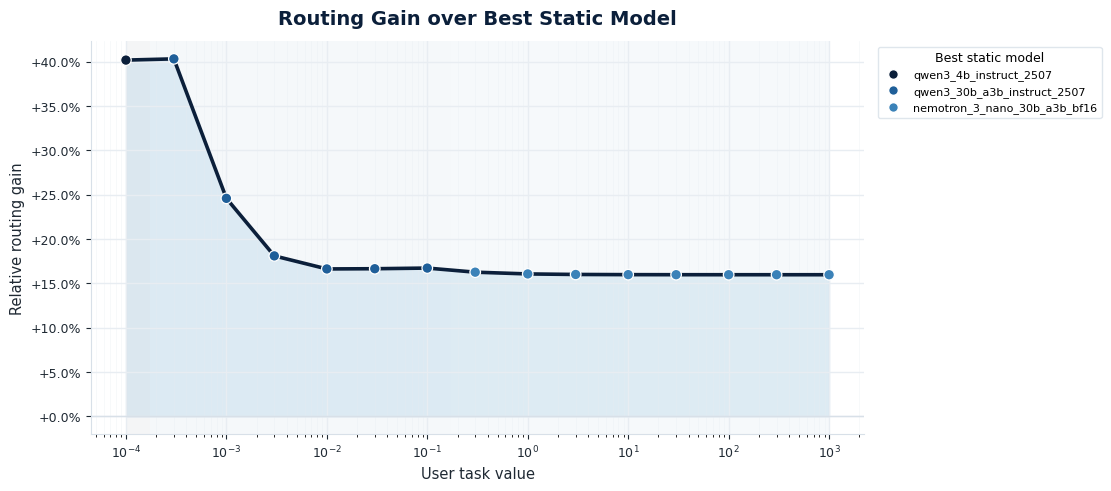

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator
from matplotlib.lines import Line2D

# Navy / steel / blue palette
NAVY = "#0B1F3A"
BLUE = "#1F5F99"
BRIGHT_BLUE = "#2E86C1"
STEEL = "#6F8499"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"

values = np.array([
    1e-4, 3e-4, 1e-3, 3e-3, 1e-2,
    3e-2, 1e-1, 3e-1, 1e0, 3e0,
    1e1, 3e1, 1e2, 3e2, 1e3,
])

def fmt_value(x):
    return f"{x:.0e}".replace("e-0", "e-").replace("e+0", "e+")

def fmt_pct(x, _):
    return f"+{100 * x:.1f}%"

# value -> model x task matrix of max_c q(c) * V - c
utility_at_values = {
    V: np.full((n_models, n_tasks), np.nan)
    for V in values
}

best_cost_at_values = {
    V: np.full((n_models, n_tasks), np.nan)
    for V in values
}

for m in range(n_models):
    grid = np.asarray(all_curves[m]["grid"])          # [n_grid]
    curves = np.asarray(all_curves[m]["curves"])      # [n_tasks, n_grid]

    for V in values:
        utility = curves * V - grid[None, :]          # [n_tasks, n_grid]
        best_idx = utility.argmax(axis=1)             # [n_tasks]

        utility_at_values[V][m, :] = utility[np.arange(n_tasks), best_idx]
        best_cost_at_values[V][m, :] = grid[best_idx]

welfare_rows = []

for V, U in utility_at_values.items():
    routed_per_task = U.max(axis=0)                   # max_i U_ij
    static_per_model = U.sum(axis=1)                  # sum_j U_ij

    routed_welfare = routed_per_task.sum()
    static_welfare = static_per_model.max()
    best_static_model_idx = static_per_model.argmax()

    welfare_rows.append({
        "value": V,
        "optimal_routed_welfare": routed_welfare,
        "optimal_static_welfare": static_welfare,
        "routing_gain": routed_welfare - static_welfare,
        "relative_gain": (
            routed_welfare / static_welfare - 1
            if static_welfare != 0 else np.nan
        ),
        "routed_welfare_per_task": routed_welfare / n_tasks,
        "static_welfare_per_task": static_welfare / n_tasks,
        "per_task_gain": (routed_welfare - static_welfare) / n_tasks,
        "best_static_model_idx": best_static_model_idx,
        "best_static_model": models[best_static_model_idx],
    })

welfare_df = pd.DataFrame(welfare_rows).sort_values("value").reset_index(drop=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator
from matplotlib.lines import Line2D

# Palette
NAVY = "#0B1F3A"
BLUE = "#1F5F99"
BRIGHT_BLUE = "#2E86C1"
STEEL = "#6F8499"
LIGHT_STEEL = "#D8E0E8"
GRID = "#E8EDF2"
TEXT = "#1F2933"

BASE_COLORS = [
    "#0B1F3A", "#1F5F99", "#3B82B8", "#6F8499", "#2F6F73",
    "#536D88", "#174A7C", "#8AA7BF", "#405D78", "#2B3F63",
]

def fmt_pct(x, _):
    return f"+{100 * x:.1f}%"

# Color markers by best static model
unique_static_models = list(dict.fromkeys(welfare_df["best_static_model"]))
model_color = {
    model: BASE_COLORS[i % len(BASE_COLORS)]
    for i, model in enumerate(unique_static_models)
}
point_colors = welfare_df["best_static_model"].map(model_color)

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)

# Main relative gain curve
ax.plot(
    welfare_df["value"],
    welfare_df["relative_gain"],
    linewidth=2.6,
    color=NAVY,
    zorder=3,
)

ax.scatter(
    welfare_df["value"],
    welfare_df["relative_gain"],
    s=58,
    c=point_colors,
    edgecolor="white",
    linewidth=0.9,
    zorder=4,
)

ax.fill_between(
    welfare_df["value"],
    0,
    welfare_df["relative_gain"],
    color=BRIGHT_BLUE,
    alpha=0.12,
    zorder=1,
)

# Lightly shade contiguous regions with the same best static model
segments = []
start = 0

for i in range(1, len(welfare_df)):
    if welfare_df.loc[i, "best_static_model"] != welfare_df.loc[start, "best_static_model"]:
        segments.append((start, i - 1))
        start = i

segments.append((start, len(welfare_df) - 1))

for start, end in segments:
    model = welfare_df.loc[start, "best_static_model"]
    x0 = welfare_df.loc[start, "value"]
    x1 = welfare_df.loc[end, "value"]

    # Extend segment halfway to neighboring log-points
    if start > 0:
        x0 = np.sqrt(welfare_df.loc[start - 1, "value"] * welfare_df.loc[start, "value"])
    if end < len(welfare_df) - 1:
        x1 = np.sqrt(welfare_df.loc[end, "value"] * welfare_df.loc[end + 1, "value"])

    ax.axvspan(
        x0,
        x1,
        color=model_color[model],
        alpha=0.045,
        linewidth=0,
        zorder=0,
    )

# Annotate only representative per-task gain values, not every point
annot_idx = np.linspace(0, len(welfare_df) - 1, 5).round().astype(int)

# for idx in annot_idx:
#     row = welfare_df.iloc[idx]
#     ax.annotate(
#         f"+{row['per_task_gain']:.2g}/task",
#         xy=(row["value"], row["relative_gain"]),
#         xytext=(0, 12),
#         textcoords="offset points",
#         ha="center",
#         va="bottom",
#         fontsize=8.5,
#         color=TEXT,
#         bbox=dict(
#             boxstyle="round,pad=0.22",
#             facecolor="white",
#             edgecolor=LIGHT_STEEL,
#             alpha=0.92,
#         ),
#         arrowprops=dict(
#             arrowstyle="-",
#             color=LIGHT_STEEL,
#             linewidth=0.8,
#         ),
#     )

ax.set_xscale("log")
ax.set_xlabel("User task value", fontsize=10.5, color=TEXT)
ax.set_ylabel("Relative routing gain", fontsize=10.5, color=TEXT)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.xaxis.set_major_locator(LogLocator(base=10))

ax.set_title(
    "Routing Gain over Best Static Model",
    fontsize=14,
    fontweight="semibold",
    color=NAVY,
    pad=12,
)

ax.axhline(0, color=LIGHT_STEEL, linewidth=1)
ax.grid(True, which="major", color=GRID, linewidth=1)
ax.grid(True, which="minor", color=GRID, linewidth=0.5, alpha=0.45)

ax.tick_params(axis="both", labelsize=9, colors=TEXT)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(LIGHT_STEEL)
ax.spines["bottom"].set_color(LIGHT_STEEL)

# Compact legend instead of overlapping model labels on the curve
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markersize=7,
        markerfacecolor=model_color[model],
        markeredgecolor="white",
        label=model,
    )
    for model in unique_static_models
]

ax.legend(
    handles=handles,
    title="Best static model",
    title_fontsize=9,
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor=LIGHT_STEEL,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
)

plt.show()

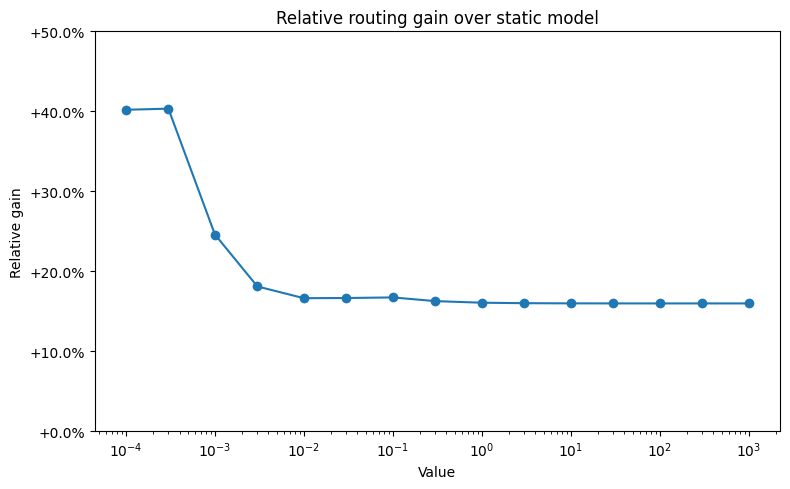

In [108]:
welfare_df["relative_gain"] = (
    welfare_df["optimal_routed_welfare"] / welfare_df["optimal_static_welfare"] - 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    welfare_df["value"],
    welfare_df["relative_gain"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Value")
plt.ylabel("Relative gain")
plt.ylim(0, 0.5)
plt.title("Relative routing gain over static model")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"+{100*x:.1f}%")
plt.tight_layout()
plt.show()